# Pairs Trading with Spread Residual and Cycle Analysis

Pairs trading usually starts with a spread z-score. De-Time can help separate spread trend drift from residual mean reversion. A spread that trends persistently is often a broken relative-value trade, not a cheap entry.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
for path in [ROOT / "src", ROOT / "examples"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

In [2]:
pair_prices = fetch_yahoo_prices(["KO", "PEP"], start="2016-01-01", cache_dir=ROOT / "examples" / "quant_trading" / "data" / "cache")
weights = pair_trading_weights(pair_prices["KO"], pair_prices["PEP"], lookback=120, entry_z=1.5, exit_z=0.25)
result = backtest_weights(pair_prices, weights, fee_bps=1.0, slippage_bps=2.0)
result.stats_frame()

,value
total_return,0.082358
cagr,0.007665
volatility,0.064502
sharpe,0.150697
max_drawdown,-0.195764
calmar,0.039152
hit_rate,0.351838
average_turnover,0.021288
average_gross_exposure,0.707887
fee_bps,1.000000


In [3]:
spread = np.log(pair_prices["KO"]) - np.log(pair_prices["PEP"])
spread_frame = decompose_one_series(spread.add(100.0), method="STL", period=63, use_log_price=False)
spread_frame[["transformed_price", "trend", "residual", "residual_z"]].tail()

,transformed_price,trend,residual,residual_z
Date,,,,
2026-05-18,99.392566,99.328071,0.016120,1.401474
2026-05-19,99.392644,99.329103,0.022717,1.769487
2026-05-20,99.395326,99.330141,0.029684,2.133987
2026-05-21,99.393607,99.331185,0.025161,1.775436
2026-05-22,99.391160,99.332235,0.027908,1.902002


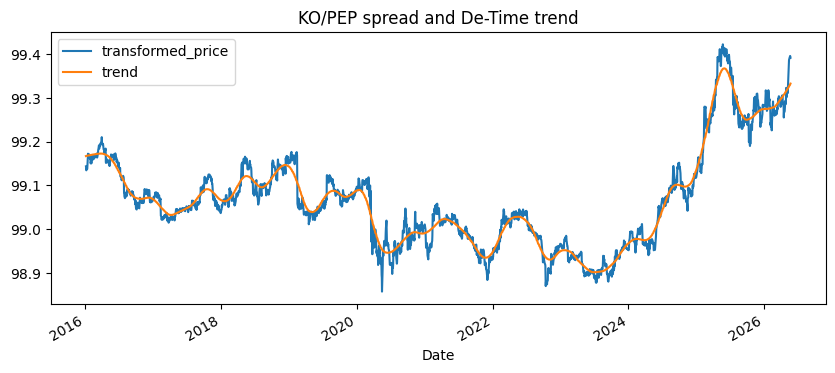

In [4]:
spread_frame[["transformed_price", "trend"]].plot(figsize=(10, 4), title="KO/PEP spread and De-Time trend")
plt.show()